# Similarity analysis on hashed fingerprints (ECFP)

In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# 1. Load the dataframe
df = pd.read_csv('../my_data/structures_best.csv')

# 2. Create the rdmol column (RDKit Molecule objects)
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 3. Create RDKit molecule objects
df['rdmol'] = df['Canonical_SMILES'].apply(Chem.MolFromSmiles)

# 4. Generate ECFP fingerprints using GetFingerprint
# This returns an ExplicitBitVect which we then convert to a string
df['ECFP'] = df['rdmol'].apply(
    lambda m: fp_gen.GetFingerprint(m).ToBitString() if m else None
)

# Preview
print(df[['Canonical_SMILES', 'ECFP']].head())

                                    Canonical_SMILES  \
0  CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...   
1  CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...   
3  CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...   
4  C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...   

                                                ECFP  
0  0100000000000000000000000000000000000000010000...  
1  0100000000000000000000000000000000000000000000...  
2  0100000000000000000000000000000000000000000000...  
3  0100000000000000000000000000000000000000000000...  
4  0100010000000000000100000000000000000010000000...  


## Butina Clustering (Hierarchical Clustering based on Tanimoto distance)
1) Prepare distance matrix (tanimoto)
2) Run Butina clustering
3) Plot results

In [47]:
reduced = df[df["Source"] == "ChEMBL ID"].sample(1000)

Our reduced dataset is structurally sparsed, therefore I chose only chembl source to get better clustering results.

In [49]:
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina

# 1. Prepare fingerprints as a list of RDKit objects
# (Butina needs the actual BitVect objects, not the bitstrings)
mols = [m for m in reduced['rdmol'] if m is not None]
fps = [fp_gen.GetFingerprint(m) for m in mols]

# 2. Calculate the distance matrix (1 - Similarity)
def tanimoto_distance_matrix(fp_list):
    dissimilarity_matrix = []
    for i in range(1, len(fp_list)):
        # Calculate distance to all previous fingerprints
        sims = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
        # Convert similarity to distance
        dissimilarity_matrix.extend([1 - x for x in sims])
    return dissimilarity_matrix

dist_matrix = tanimoto_distance_matrix(fps)

# 3. Run Butina Clustering
# distThreshold: Clusters molecules with Tanimoto distance <= 0.2 (80% similarity)
clusters_25 = Butina.ClusterData(dist_matrix, len(fps), distThresh=0.25, isDistData=True)
clusters_50 = Butina.ClusterData(dist_matrix, len(fps), distThresh=0.5, isDistData=True)
clusters_75 = Butina.ClusterData(dist_matrix, len(fps), distThresh=0.75, isDistData=True)
clusters_90 = Butina.ClusterData(dist_matrix, len(fps), distThresh=0.9, isDistData=True)


# 4. Process results
print(f"Found {len(clusters_25)} clusters.")
print(f"Found {len(clusters_50)} clusters.")
print(f"Found {len(clusters_75)} clusters.")
print(f"Found {len(clusters_90)} clusters.")

Found 616 clusters.
Found 160 clusters.
Found 46 clusters.
Found 6 clusters.


As we increase the distance threshold, we expect to see fewer clusters (more diverse groups):

Note, that we are plotting with log() scale for better visibility.

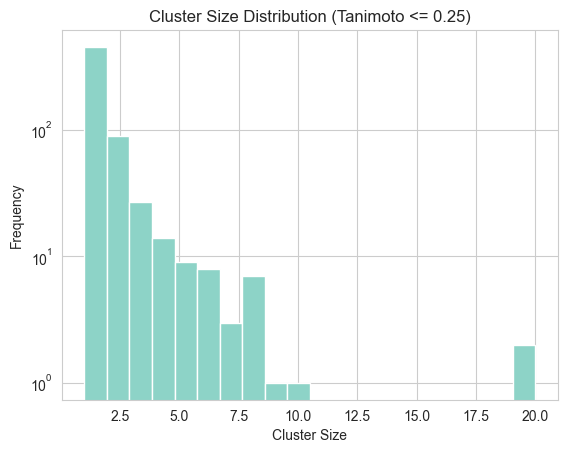

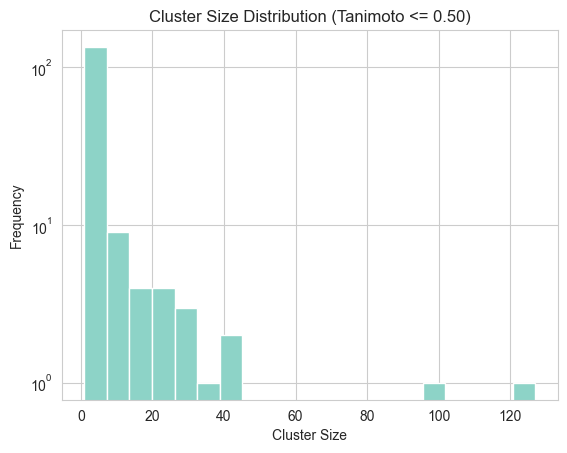

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")

def plot_cluster_distribution(clusters, title):
    cluster_sizes = [len(c) for c in clusters]
    plt.hist(cluster_sizes, bins=20)
    plt.xlabel('Cluster Size')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.yscale('log')
    plt.show()

plot_cluster_distribution(clusters_25, 'Cluster Size Distribution (Tanimoto <= 0.25)')
plot_cluster_distribution(clusters_50, 'Cluster Size Distribution (Tanimoto <= 0.50)')

Note, that butina threshold over 0.5 is too permissive. Standard values are 0.2 (tight) to 0.4 (similar scaffolds).

Also, let's look at the distance matrix:

<Axes: ylabel='Count'>

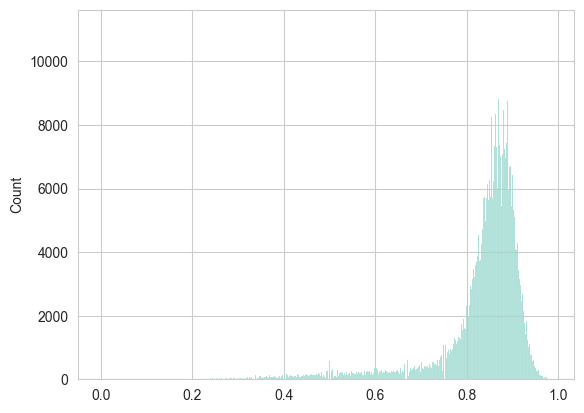

In [52]:
sns.histplot(dist_matrix)

Interpretation:
* 0.0 - identical molecules (distance = 0)
* 1.0 - completely different molecules (distance = 1)

Let's distinguish the sources (ZINC, DrugBank, ChEMBL) and see if they have different distance distributions:

Source zincid: 356 rows found
Source zincid: 356 fingerprints generated
Source drugbank_id: 395 rows found
Source drugbank_id: 395 fingerprints generated
Source ChEMBL ID: 249 rows found
Source ChEMBL ID: 249 fingerprints generated


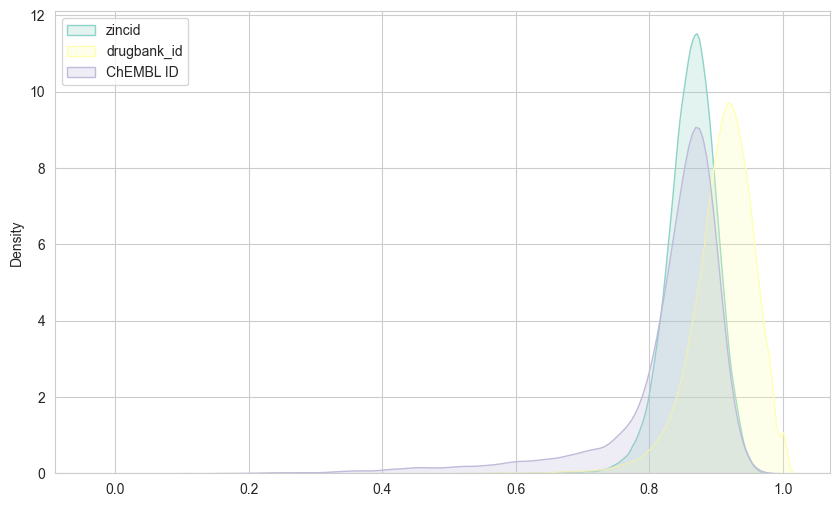

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
df = df.sample(1000)

# Create a dictionary to hold distances for each source
source_distances = {}

for source_name in ['ZINC', 'DrugBank', 'chembl']:
    # 1. Filter fingerprints by source
    source_fps = [
        fp_gen.GetFingerprint(m)
        for m, s in zip(df['rdmol'], df['Source'])
        if m is not None and s == source_name
    ]
    if source_fps:
        source_distances[source_name] = tanimoto_distance_matrix(source_fps)

for name in ['zincid', 'drugbank_id', 'ChEMBL ID']:
    subset = df[df['Source'] == name]
    print(f"Source {name}: {len(subset)} rows found")
    source_fps = [fp_gen.GetFingerprint(m) for m in subset['rdmol'] if m is not None]
    print(f"Source {name}: {len(source_fps)} fingerprints generated")
    if len(source_fps) > 1:
        source_distances[name] = tanimoto_distance_matrix(source_fps)
    else:
        print(f"Warning: Not enough data for {name} to calculate distances.")

plt.figure(figsize=(10, 6))
for name, distances in source_distances.items():
    if distances: # Ensure list isn't empty
        sns.kdeplot(distances, label=name, fill=True)

plt.legend()
plt.show()

Here we can see the overlaying sources.

Now we will look at the butina results (for chembl with threshold 0.25) in TSNE with different perplexities.

In [58]:
from sklearn.manifold import TSNE
import numpy as np

# 1. Convert RDKit fingerprints to a NumPy array for t-SNE
np_fps = []
for fp in fps:
    arr = np.zeros((1,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    np_fps.append(arr)
np_fps = np.array(np_fps)

# 2. Map molecules to Cluster IDs
# Butina returns a tuple of tuples: ((idx1, idx2), (idx3,), ...)
cluster_labels = np.zeros(len(fps), dtype=int)
for cluster_id, cluster_indices in enumerate(clusters_25):
    for idx in cluster_indices:
        cluster_labels[idx] = cluster_id

C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
C:\Users\souku\PycharmProjects\cdd2026\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2459: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


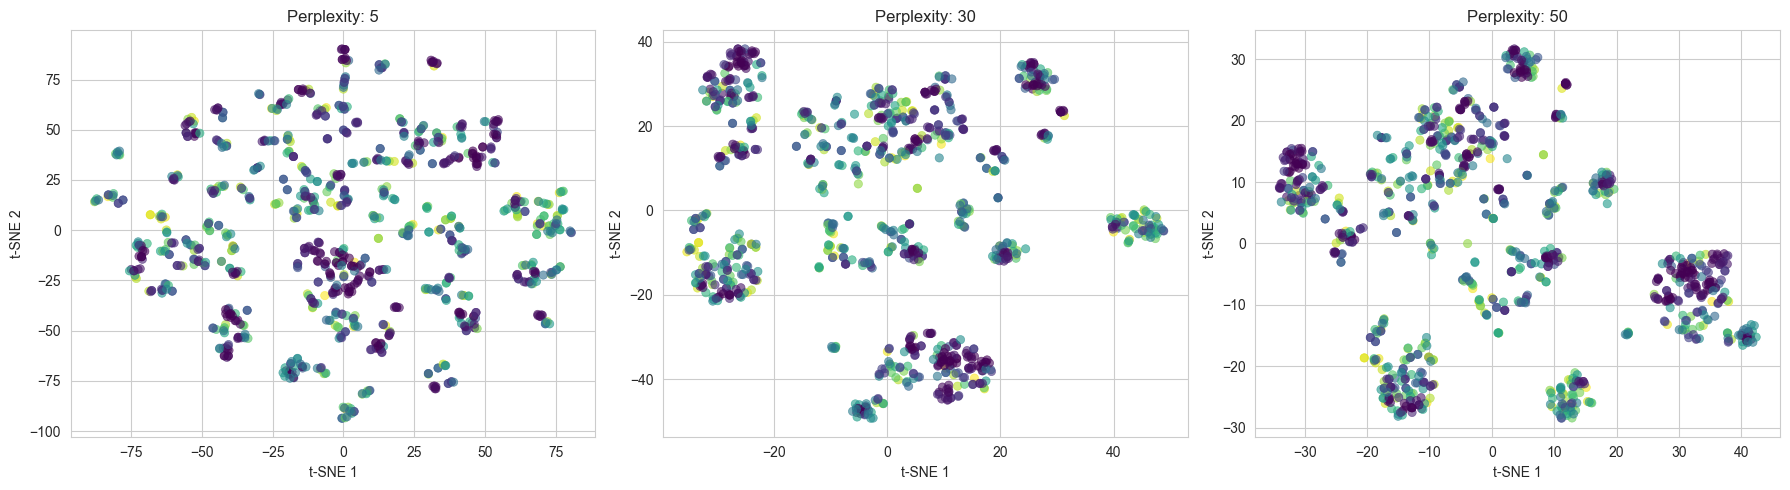

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne_perplexities(data, labels, perplexities=[5, 30, 50]):
    n_plots = len(perplexities)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    for i, perp in enumerate(perplexities):
        # 1. Run t-SNE
        tsne = TSNE(
            n_components=2,
            metric='jaccard',
            init='random', # 'pca' init often doesn't support precomputed/jaccard well in all versions
            perplexity=perp,
            learning_rate='auto',
            random_state=42
        )
        results = tsne.fit_transform(data)

        sns.scatterplot(
            x=results[:, 0],
            y=results[:, 1],
            hue=labels,
            palette='viridis',
            ax=axes[i],
            legend=None,
            alpha=0.6,
            edgecolor=None
        )

        axes[i].set_title(f"Perplexity: {perp}")
        axes[i].set_xlabel("t-SNE 1")
        axes[i].set_ylabel("t-SNE 2")

    plt.tight_layout()
    plt.show()

plot_tsne_perplexities(np_fps, cluster_labels, perplexities=[5, 30, 50])

## Diversity selection
Rdkit has a built-in function to select a diverse subset of molecules based on their fingerprints: SimDivFilters.

In [67]:
from rdkit import Chem, DataStructs, SimDivFilters
from rdkit.Chem import AllChem

# 1. Convert strings back to BitVects
# If your 'ECFP' column contains bitstrings (e.g., '1011...'):
fps = [DataStructs.CreateFromBitString(s) for s in df['ECFP']]

# 2. Re-run the picker
n_to_select = 100
picker = SimDivFilters.MaxMinPicker()
selected_indices = picker.LazyBitVectorPick(fps, len(fps), n_to_select)

# 3. Slice your dataframe
diverse_df = reduced.iloc[list(selected_indices)]

In *diverse_df* we now have a subset of 100 molecules that are as diverse as possible based on their ECFP fingerprints ("representative snapshot").

In [68]:
diverse_df

,Canonical_SMILES,Source,rdmol,ECFP
9090,CCc1nccc(-c2ccc(C(=O)N3CCCOCC3)c(F)c2)c1C#Cc1c...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000010000000000000000000000000000000000...
9985,Cc1ncnc(-c2ccc(C(=O)N3CCCO3)c(Cl)c2)c1C#Cc1ccc...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
11626,C[C@@H]1COCCN1c1cc(C2(S(C)(=O)=O)CC2)nc(-c2ccc...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000100000000100000000...
8306,CCNC(=O)Nc1ccc(-c2nc(N3CCOC[C@@H]3C)c3c(n2)[C@...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000100000000...
9512,CCc1ncnc(-c2ccc(C(=O)N3CCC(N4CCOCC4)CC3)c(F)c2...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
...,...,...,...,...
9693,Cc1nc(N)ccc1C#Cc1c(-c2ccc(S(C)(=O)=O)cc2)ccnc1C,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
11319,CSc1cnc(-c2ccc(NC(=O)Nc3ccc(N4CCOCC4)cc3)cc2)n...,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
7539,Nc1ncnc2c1c(-c1ccc(Cl)c(O)c1)nn2[C@@H]1CCOC1,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
8048,Oc1cccc(-c2nc(N3CCOCC3)c3[nH]ccc3n2)c1,ChEMBL ID,<rdkit.Chem.rdchem.Mol object at 0x000002701C0...,0000000000000000000000000000000000000000000000...
